# FMCG Profit
Covers EDA, visualization, feature engineering, preprocessing, multi-model comparison, and evaluation.

## 1. Exploratory Data Analysis

We start by understanding the structure and quality of the data. No transformations happen here — just observation. All plots use seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme()
%matplotlib inline

In [2]:
url = 'https://raw.githubusercontent.com/karan092002/fmcg-sales/refs/heads/main/data/fmcg_sales_marketing_profitability_2023_2025.csv'
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
print()
print(df.dtypes)

Shape: (18240, 27)

Order_ID                object
Order_Date              object
Year                     int64
Quarter                 object
Month                    int64
Month_Name              object
Region                  object
Country                 object
City                    object
Sales_Person            object
Customer_Type           object
Sales_Channel           object
Promotion_Type          object
Product_Category        object
Brand                   object
Product_Name            object
SKU                     object
Units_Sold               int64
Unit_Price_USD         float64
Discount_Pct           float64
Gross_Sales_USD        float64
Marketing_Spend_USD    float64
COGS_USD               float64
Logistics_Cost_USD     float64
Net_Revenue_USD        float64
Profit_USD             float64
Profit_Margin_Pct      float64
dtype: object


### 1.1 Missing Values

Check both standard nulls and blank strings stored as objects, which are a common hidden null pattern in exported CSV data.

In [3]:
print("Null counts:")
print(df.isnull().sum())
print()
# Hidden nulls: blank strings in object columns
object_cols = df.select_dtypes(include="object").columns
blank_counts = (df[object_cols] == "").sum()
print("Blank string counts in object columns:")
print(blank_counts)

Null counts:
Order_ID               0
Order_Date             0
Year                   0
Quarter                0
Month                  0
Month_Name             0
Region                 0
Country                0
City                   0
Sales_Person           0
Customer_Type          0
Sales_Channel          0
Promotion_Type         0
Product_Category       0
Brand                  0
Product_Name           0
SKU                    0
Units_Sold             0
Unit_Price_USD         0
Discount_Pct           0
Gross_Sales_USD        0
Marketing_Spend_USD    0
COGS_USD               0
Logistics_Cost_USD     0
Net_Revenue_USD        0
Profit_USD             0
Profit_Margin_Pct      0
dtype: int64

Blank string counts in object columns:
Order_ID            0
Order_Date          0
Quarter             0
Month_Name          0
Region              0
Country             0
City                0
Sales_Person        0
Customer_Type       0
Sales_Channel       0
Promotion_Type      0
Product_Category 

### 1.2 Statistical Summary

Numeric columns only. We pay attention to the spread of  — wide standard deviation relative to the mean signals high variance and a meaningful prediction challenge.

In [4]:
display(df.describe().round(2))

,Year,Month,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
count,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00,18240.00
mean,2024.00,6.52,212.91,4.47,12.94,936.43,85.74,471.02,54.03,792.21,181.41,19.87
std,0.82,3.47,202.10,1.95,5.74,1045.61,87.55,537.35,51.27,861.24,239.53,10.57
min,2023.00,1.00,5.00,1.45,0.00,13.02,1.81,6.31,1.08,10.54,-637.50,-45.31
25%,2023.00,3.00,70.00,3.02,8.71,274.53,33.49,140.51,21.37,245.22,32.34,13.72
50%,2024.00,7.00,139.00,3.99,12.69,565.43,61.39,287.16,38.98,493.90,91.89,20.87
75%,2025.00,10.00,288.00,5.44,16.85,1213.84,107.60,599.79,69.24,1027.36,239.12,27.26
max,2025.00,12.00,1366.00,12.74,28.00,10634.12,1767.71,6473.33,628.86,8752.94,2723.00,44.49


### 1.3 Target Distribution

 is right-skewed with a long positive tail and a small left tail of unprofitable orders. We plot both a histogram and a box plot to capture shape and outliers.

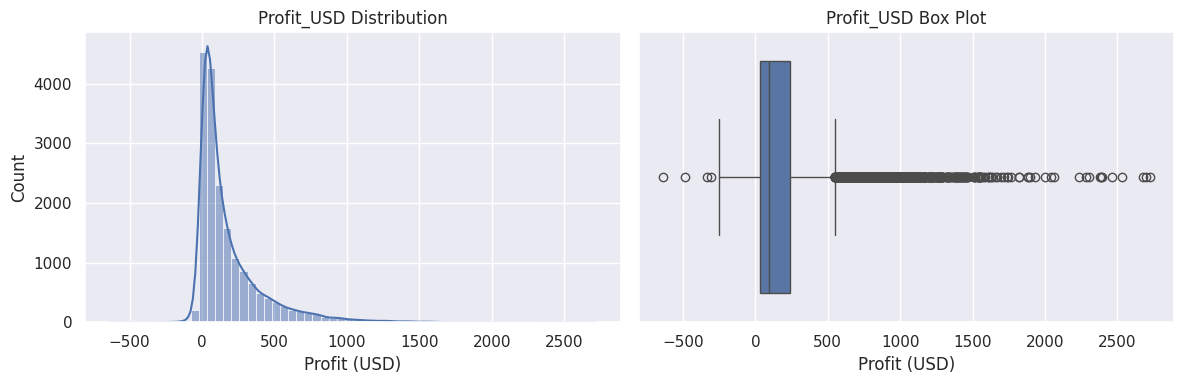

Negative profit orders: 784 (4.3%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Profit_USD"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Profit_USD Distribution")
axes[0].set_xlabel("Profit (USD)")

sns.boxplot(x=df["Profit_USD"], ax=axes[1])
axes[1].set_title("Profit_USD Box Plot")
axes[1].set_xlabel("Profit (USD)")

plt.tight_layout()
plt.show()

print(f"Negative profit orders: {(df['Profit_USD'] < 0).sum()} ({(df['Profit_USD'] < 0).mean():.1%})")

### 1.4 Profit by Categorical Features

We want to understand which segments drive profitability. These box plots show median profit and spread within each group.

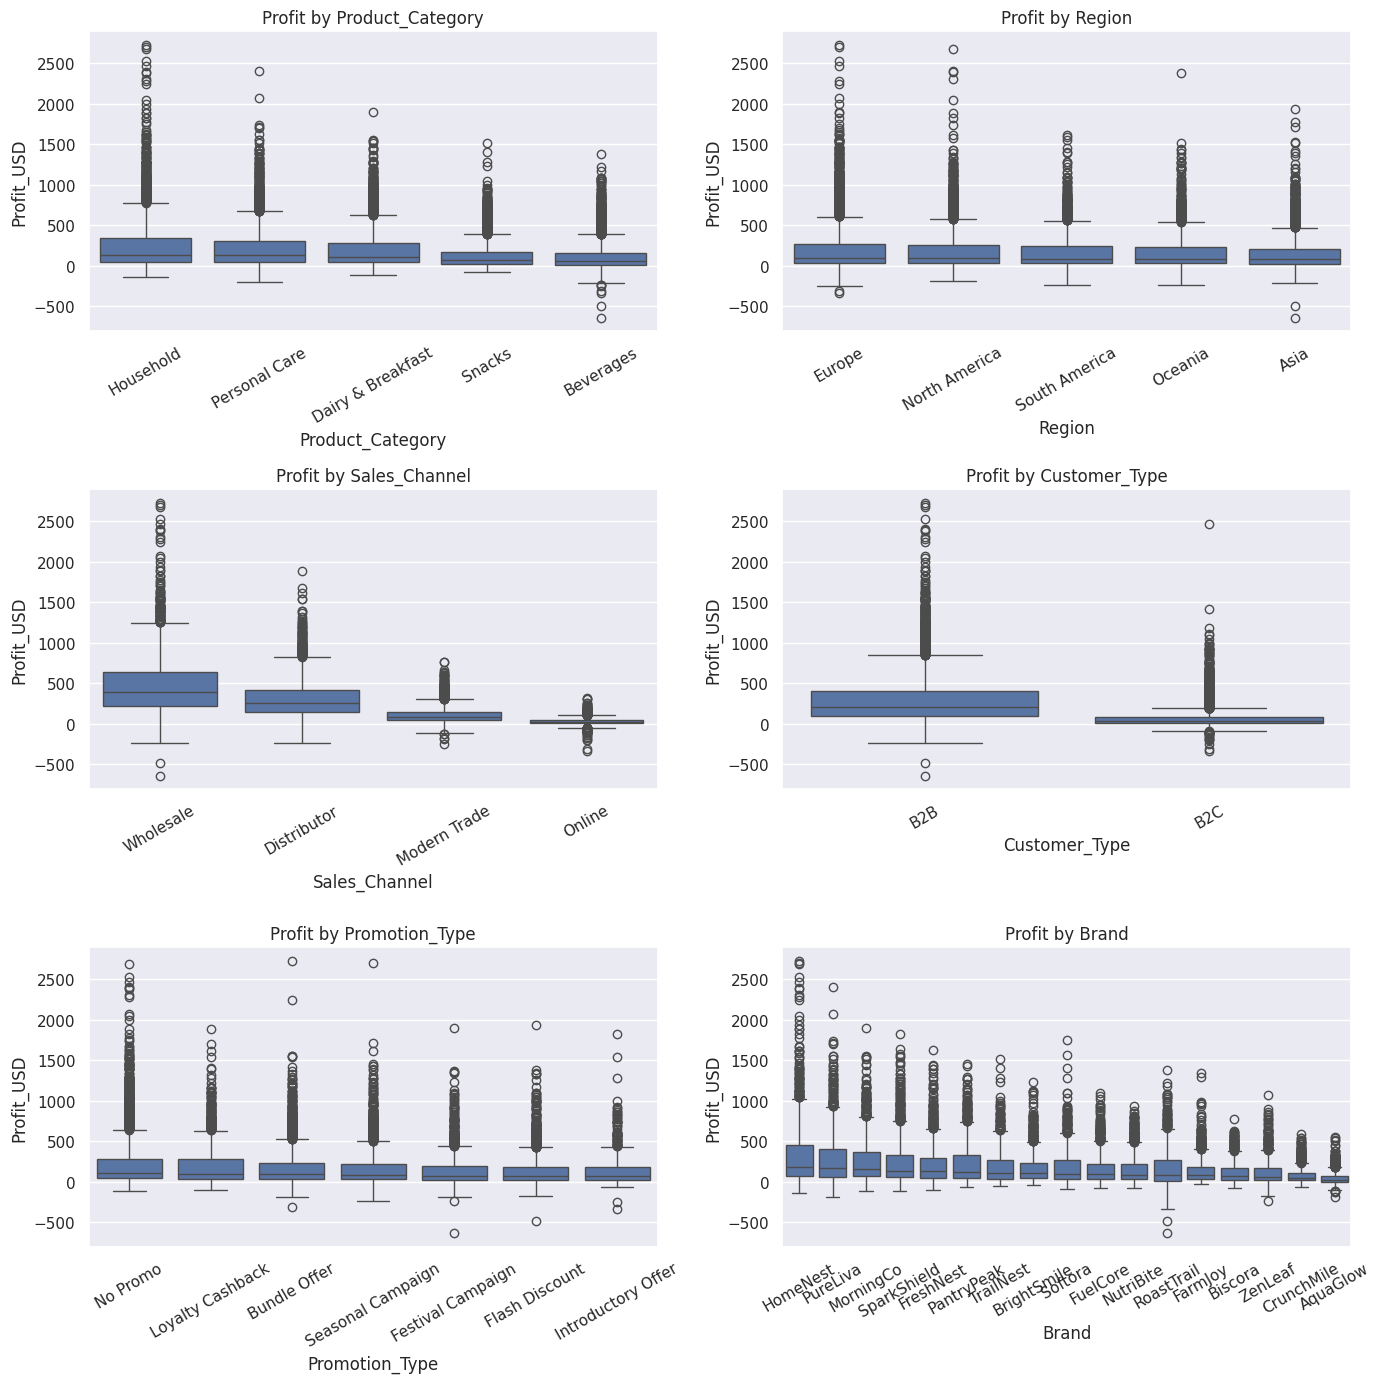

In [6]:
cat_cols = ["Product_Category", "Region", "Sales_Channel", "Customer_Type", "Promotion_Type", "Brand"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)["Profit_USD"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="Profit_USD", order=order, ax=axes[i])
    axes[i].set_title(f"Profit by {col}")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 1.5 Numeric Feature Distributions

We look at how continuous inputs are distributed — this tells us what preprocessing they need (scaling, imputation) and whether any relationships with the target are visible.

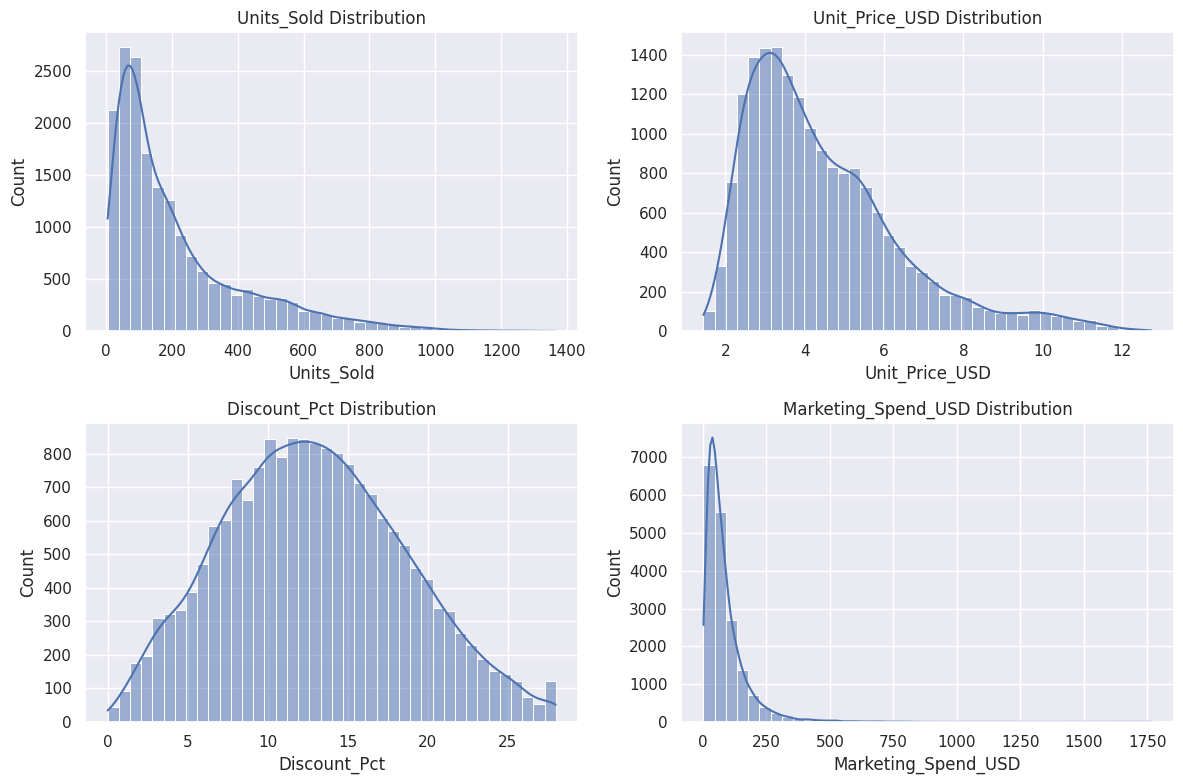

In [7]:
num_cols = ["Units_Sold", "Unit_Price_USD", "Discount_Pct", "Marketing_Spend_USD"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

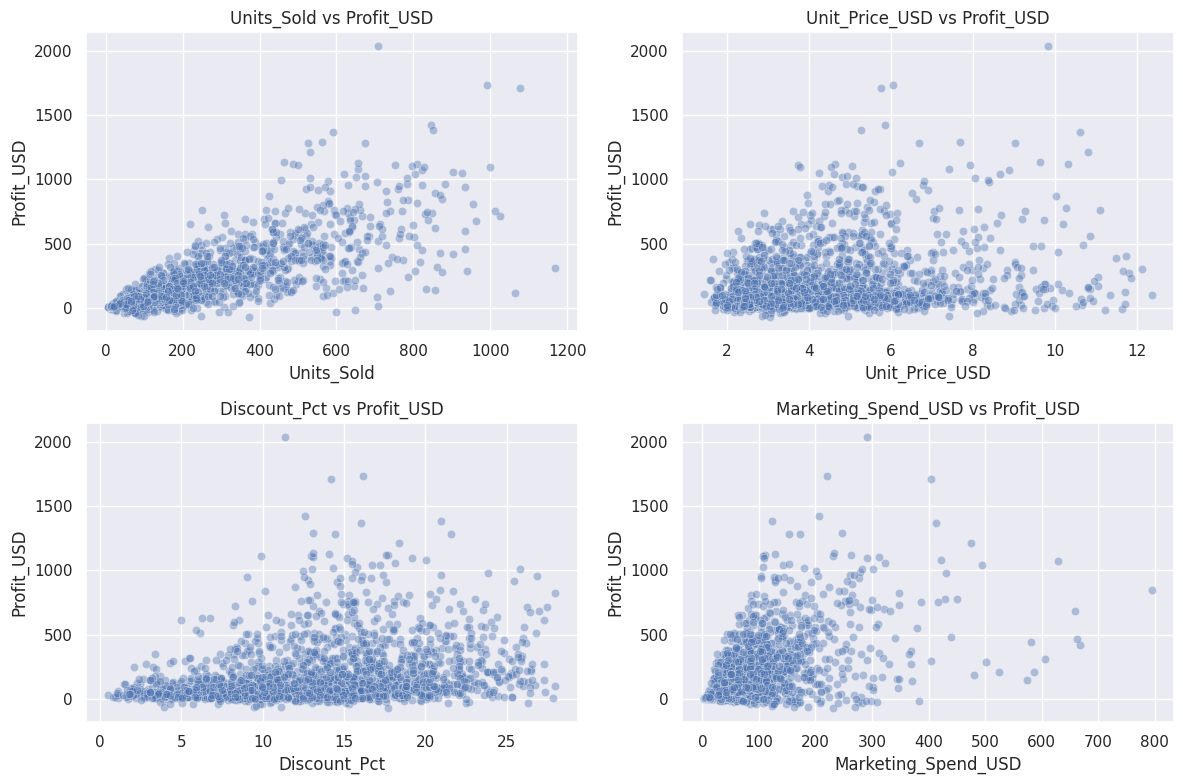

In [8]:
# Scatter plots against Profit_USD
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # sample to keep plot readable
    sample = df.sample(n=2000, random_state=42)
    sns.scatterplot(data=sample, x=col, y="Profit_USD", alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{col} vs Profit_USD")

plt.tight_layout()
plt.show()

### 1.6 Correlation Heatmap

Correlation between numeric features and the target. This drives which raw features carry signal and which engineered features we should create.

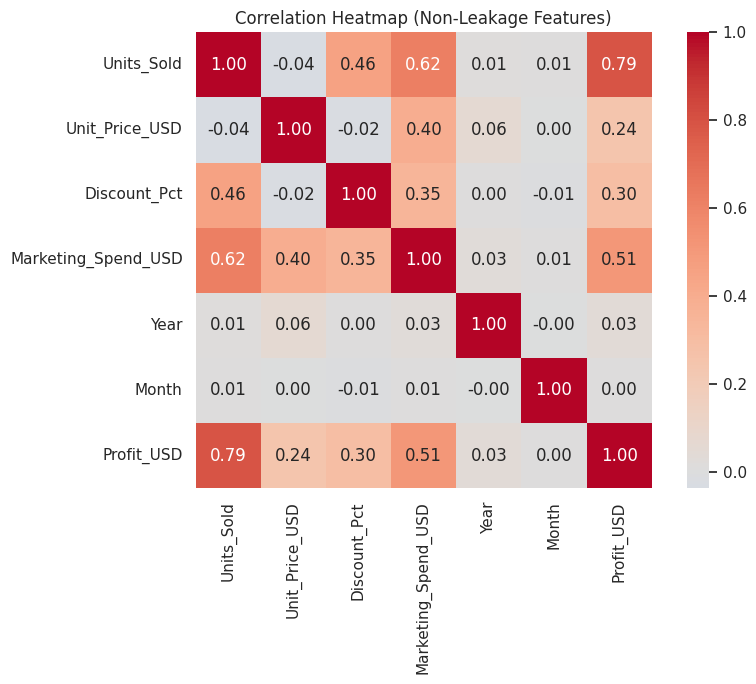

In [9]:
# Include only non-leakage numeric columns for the correlation view
corr_cols = ["Units_Sold", "Unit_Price_USD", "Discount_Pct", "Marketing_Spend_USD",
             "Year", "Month", "Profit_USD"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Non-Leakage Features)")
plt.tight_layout()
plt.show()

### 1.7 Profit by Year and Quarter

Time patterns can reveal seasonal trends or year-over-year growth that a model should capture.

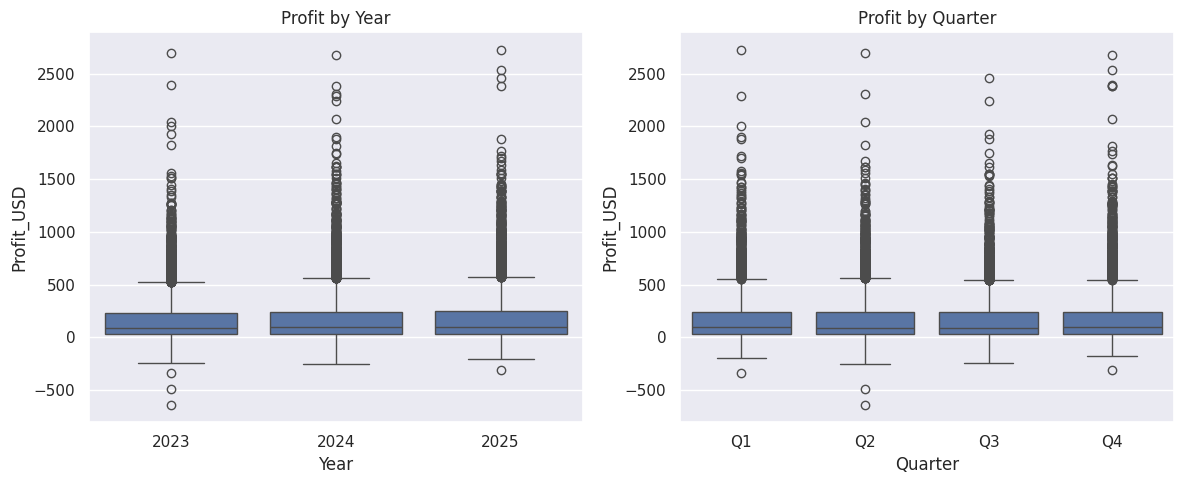

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Year", y="Profit_USD", ax=axes[0])
axes[0].set_title("Profit by Year")

sns.boxplot(data=df, x="Quarter", y="Profit_USD",
            order=["Q1","Q2","Q3","Q4"], ax=axes[1])
axes[1].set_title("Profit by Quarter")

plt.tight_layout()
plt.show()

## 2. Feature Engineering

Based on EDA, we create features that capture business logic and interaction effects. We also drop columns that would leak the target or are pure identifiers.

**Dropped columns:**
- , ,  — identifiers / redundant with time columns
- , , ,  — direct arithmetic components of ; including them would make the target trivially reconstructable
-  — derived from , causes direct leakage

**New features:**
- : unit price after discount — captures the real price a customer pays
- : units × effective price — a proxy for top-line revenue without using the official (post-cost) revenue columns
- : spend per unit sold — measures marketing efficiency
- : binary flag for any active promotion — condenses the promotion type into a signal
- : binary flag for the holiday quarter — captures the seasonal lift visible in EDA

In [11]:
df_fe = df.copy()

# New features
df_fe["Effective_Unit_Price"] = df_fe["Unit_Price_USD"] * (1 - df_fe["Discount_Pct"] / 100)
df_fe["Revenue_Estimate"] = df_fe["Units_Sold"] * df_fe["Effective_Unit_Price"]
df_fe["Marketing_Per_Unit"] = df_fe["Marketing_Spend_USD"] / df_fe["Units_Sold"]
df_fe["Is_Promoted"] = (df_fe["Promotion_Type"] != "No Promo").astype(int)
df_fe["Is_Q4"] = (df_fe["Quarter"] == "Q4").astype(int)

# Drop leakage and identifier columns
leakage_cols = [
    "Order_ID", "SKU", "Order_Date",
    "Gross_Sales_USD", "Net_Revenue_USD",
    "COGS_USD", "Logistics_Cost_USD",
    "Profit_Margin_Pct"
]
df_fe = df_fe.drop(columns=leakage_cols)

print(f"Shape after feature engineering: {df_fe.shape}")
print(f"\nColumns remaining:\n{list(df_fe.columns)}")
print(f"\nNew feature samples:")
display(df_fe[["Effective_Unit_Price","Revenue_Estimate","Marketing_Per_Unit","Is_Promoted","Is_Q4"]].describe().round(2))

Shape after feature engineering: (18240, 24)

Columns remaining:
['Year', 'Quarter', 'Month', 'Month_Name', 'Region', 'Country', 'City', 'Sales_Person', 'Customer_Type', 'Sales_Channel', 'Promotion_Type', 'Product_Category', 'Brand', 'Product_Name', 'Units_Sold', 'Unit_Price_USD', 'Discount_Pct', 'Marketing_Spend_USD', 'Profit_USD', 'Effective_Unit_Price', 'Revenue_Estimate', 'Marketing_Per_Unit', 'Is_Promoted', 'Is_Q4']

New feature samples:


,Effective_Unit_Price,Revenue_Estimate,Marketing_Per_Unit,Is_Promoted,Is_Q4
count,18240.00,18240.00,18240.00,18240.00,18240.00
mean,3.89,792.21,0.53,0.63,0.25
std,1.73,861.24,0.37,0.48,0.44
min,1.11,10.54,0.05,0.00,0.00
25%,2.62,245.22,0.28,0.00,0.00
50%,3.47,493.90,0.44,1.00,0.00
75%,4.77,1027.36,0.66,1.00,1.00
max,12.21,8752.94,5.05,1.00,1.00


## 3. Train / Test Split

We split 80/20 before any preprocessing. The test set is held completely aside until the final evaluation step. This is a regression problem so no stratification is needed — we use  with a fixed random state for reproducibility.

In [12]:
from sklearn.model_selection import train_test_split

target = "Profit_USD"
X = df_fe.drop(columns=[target])
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test: X={X_test.shape}, y={y_test.shape}")
print(f"Target stats — train: mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"Target stats — test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}")

Train: X=(14592, 23), y=(14592,)
Test: X=(3648, 23), y=(3648,)
Target stats — train: mean=180.59, std=239.83
Target stats — test:  mean=184.70, std=238.30


## 4. Preprocessing Pipeline

We build a  inside a  that applies different steps to numeric and categorical columns:

- **Numeric**: median imputation → standard scaling
- **Categorical**: most-frequent imputation → ordinal encoding with

Critically,  is called only on the training set. The test set only sees . This ensures that the scaler means/variances and the encoder category maps are learned exclusively from training data, preventing any information from the test set from influencing preprocessing — which would be data leakage.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Identify numeric and categorical columns in X_train
numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (11): ['Year', 'Month', 'Units_Sold', 'Unit_Price_USD', 'Discount_Pct', 'Marketing_Spend_USD', 'Effective_Unit_Price', 'Revenue_Estimate', 'Marketing_Per_Unit', 'Is_Promoted', 'Is_Q4']
Categorical columns (12): ['Quarter', 'Month_Name', 'Region', 'Country', 'City', 'Sales_Person', 'Customer_Type', 'Sales_Channel', 'Promotion_Type', 'Product_Category', 'Brand', 'Product_Name']


In [14]:
# Build the preprocessor
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,  numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Fit on train only — transform both
# This is the crucial step that prevents data leakage
X_train_arr = preprocessor.fit_transform(X_train)
X_test_arr = preprocessor.transform(X_test)

print(f"X_train processed shape: {X_train_arr.shape}")
print(f"X_test  processed shape: {X_test_arr.shape}")

X_train processed shape: (14592, 23)
X_test  processed shape: (3648, 23)


## 5. Multiple Model Comparison

We train nine regressors on the preprocessed training data and compare them on the test set. Primary metric is R² (proportion of variance explained). Secondary metrics are RMSE (penalises large errors) and MAE (more robust to outliers). We also run 5-fold cross-validation scored on R² to check that test performance is not an artefact of the particular split.

In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel="rbf"),
    "KNN": KNeighborsRegressor(n_neighbors=5),
}

In [16]:
results = []

for name, model in models.items():
    model.fit(X_train_arr, y_train)
    preds = model.predict(X_test_arr)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    cv_scores = cross_val_score(
        model, X_train_arr, y_train,
        cv=5, scoring="r2", n_jobs=-1
    )

    results.append({
        "Model": name,
        "R2": round(r2, 4),
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
    })
    print(f"{name:<25} R2={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}  CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print("Comparison Table (sorted by R²) ---")
display(results_df)

Linear Regression         R2=0.8972  RMSE=76.40  MAE=44.87  CV=0.8866±0.0054
Ridge                     R2=0.8972  RMSE=76.40  MAE=44.87  CV=0.8866±0.0054
Lasso                     R2=0.8970  RMSE=76.46  MAE=44.83  CV=0.8864±0.0055
Decision Tree             R2=0.9278  RMSE=64.03  MAE=34.97  CV=0.9154±0.0109
Random Forest             R2=0.9630  RMSE=45.82  MAE=24.73  CV=0.9561±0.0041
Gradient Boosting         R2=0.9675  RMSE=42.93  MAE=25.85  CV=0.9607±0.0043
AdaBoost                  R2=0.3523  RMSE=191.76  MAE=170.73  CV=0.4437±0.1394
SVR                       R2=0.0392  RMSE=233.55  MAE=132.75  CV=0.0128±0.0036
KNN                       R2=0.3890  RMSE=186.24  MAE=120.46  CV=0.3984±0.0041
Comparison Table (sorted by R²) ---


,Model,R2,RMSE,MAE,CV Mean,CV Std
0,Gradient Boosting,0.9675,42.93,25.85,0.9607,0.0043
1,Random Forest,0.9630,45.82,24.73,0.9561,0.0041
2,Decision Tree,0.9278,64.03,34.97,0.9154,0.0109
3,Linear Regression,0.8972,76.40,44.87,0.8866,0.0054
4,Ridge,0.8972,76.40,44.87,0.8866,0.0054
5,Lasso,0.8970,76.46,44.83,0.8864,0.0055
6,KNN,0.3890,186.24,120.46,0.3984,0.0041
7,AdaBoost,0.3523,191.76,170.73,0.4437,0.1394
8,SVR,0.0392,233.55,132.75,0.0128,0.0036


In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model: {best_model_name}  (R² = {results_df.iloc[0]['R2']})")

Best model: Gradient Boosting  (R² = 0.9675)


## 6. Evaluation

We produce a comprehensive set of diagnostic plots to understand where each model performs well and where it falls short.

### 6.1 Model Comparison Bar Chart

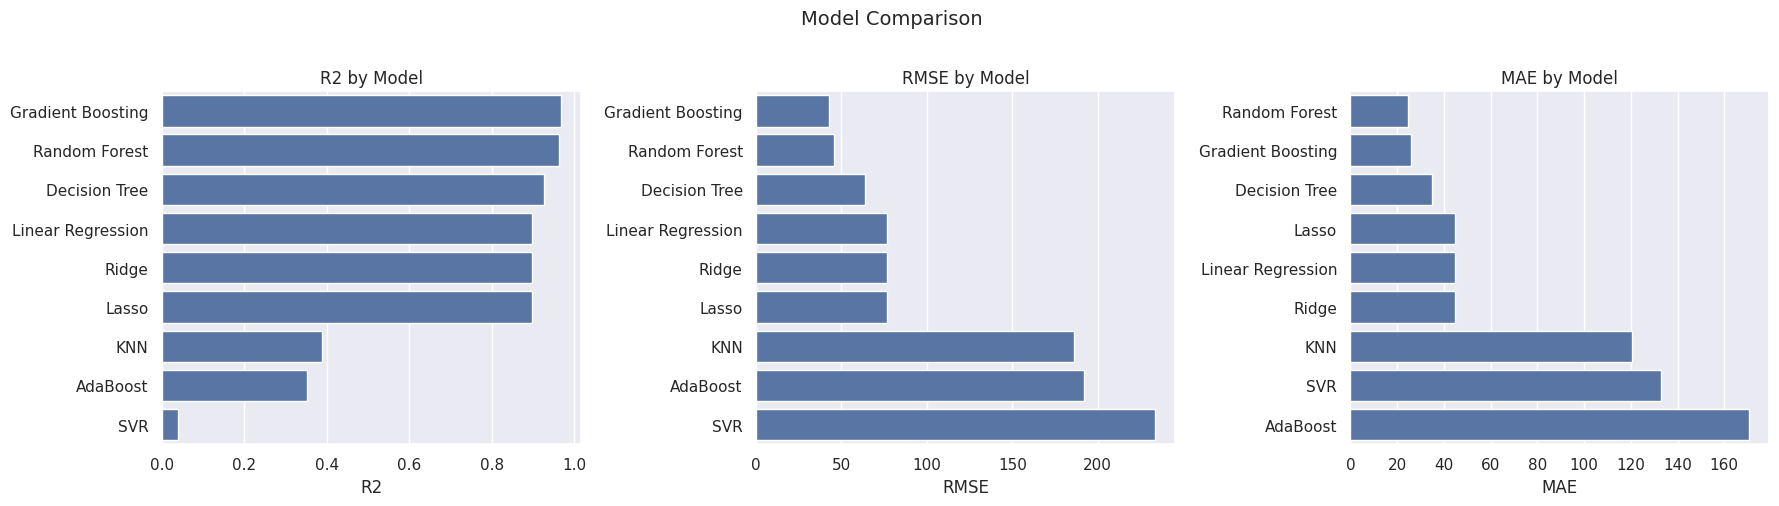

In [18]:
metrics = ["R2", "RMSE", "MAE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    ascending = metric != "R2"   # lower is better for RMSE and MAE
    plot_df = results_df.sort_values(metric, ascending=ascending)
    sns.barplot(data=plot_df, x=metric, y="Model", ax=ax)
    ax.set_title(f"{metric} by Model")
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.suptitle("Model Comparison", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Actual vs Predicted — Top 4 Models

The ideal model produces points along the diagonal. Scatter above or below reveals systematic bias.

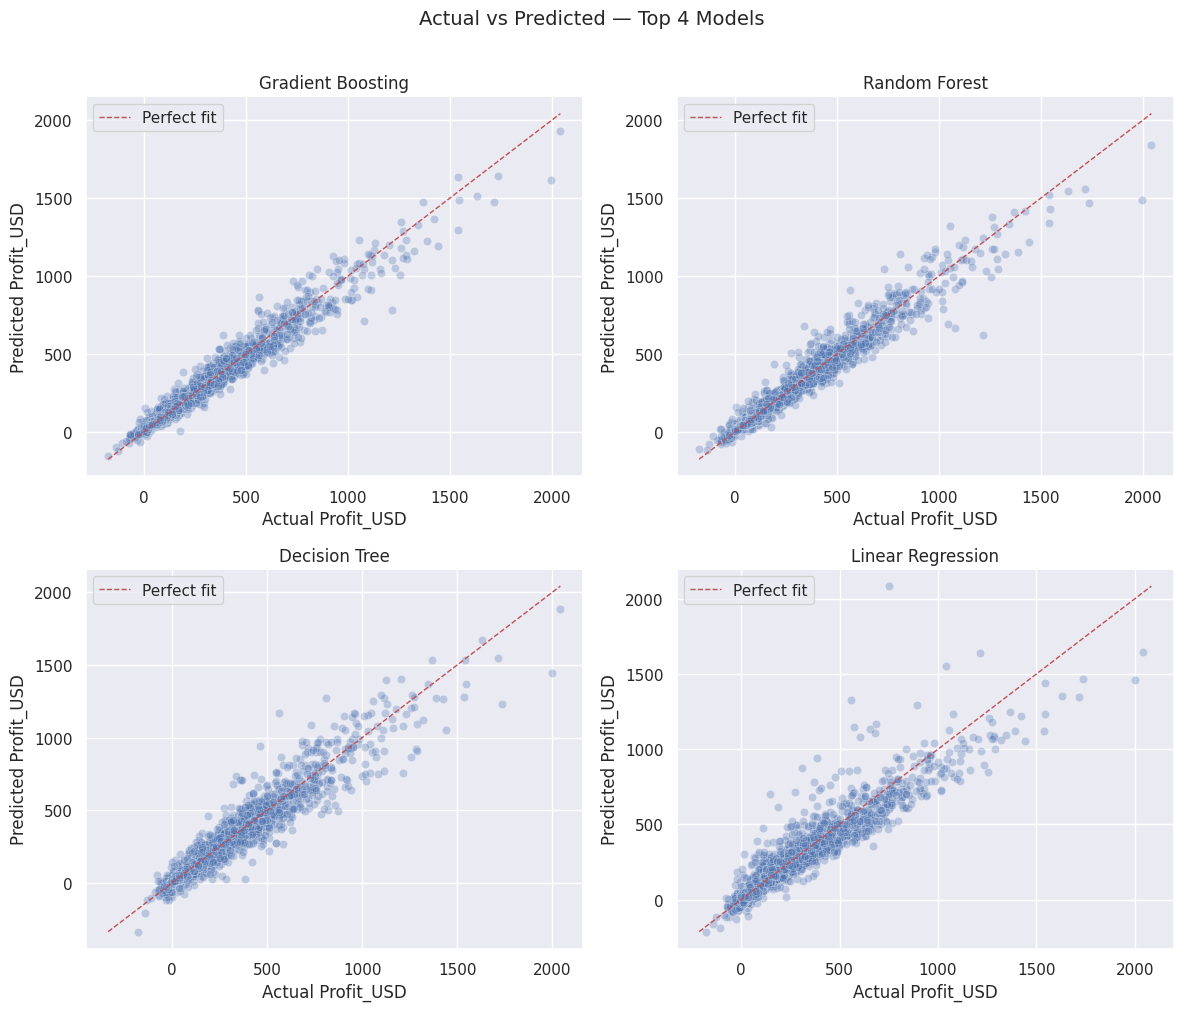

In [19]:
top4_names = results_df.head(4)["Model"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, name in enumerate(top4_names):
    model = models[name]
    preds = model.predict(X_test_arr)
    sns.scatterplot(x=y_test, y=preds, alpha=0.3, ax=axes[i])
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    axes[i].plot(lims, lims, "r--", linewidth=1, label="Perfect fit")
    axes[i].set_xlabel("Actual Profit_USD")
    axes[i].set_ylabel("Predicted Profit_USD")
    axes[i].set_title(name)
    axes[i].legend()

plt.suptitle("Actual vs Predicted — Top 4 Models", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 Residual Plots — Top 4 Models

Residuals (actual − predicted) should be centred around zero with no pattern. Fans or curves reveal heteroscedasticity or non-linearity the model is missing.

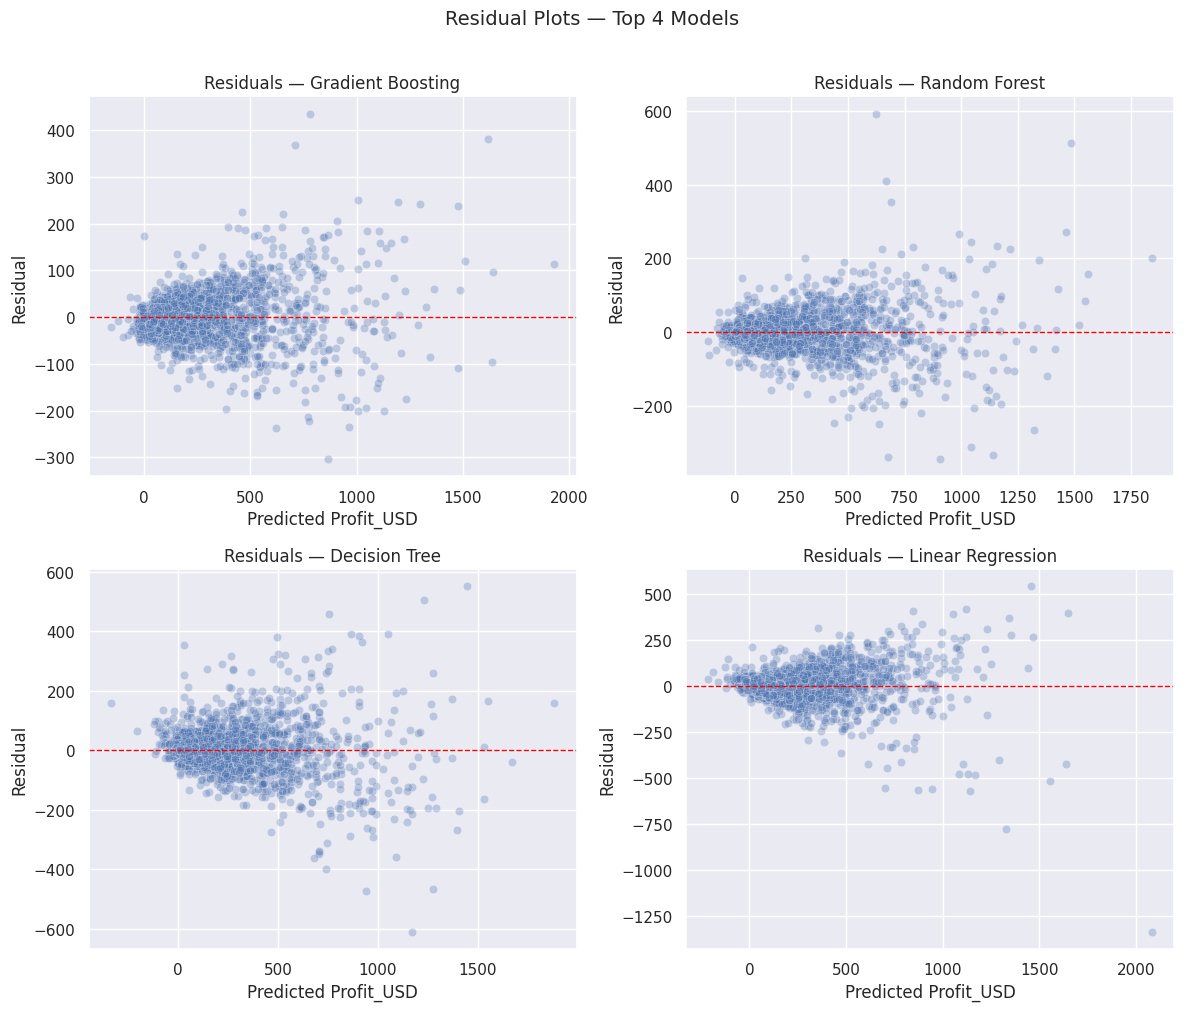

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, name in enumerate(top4_names):
    model = models[name]
    preds = model.predict(X_test_arr)
    residuals = y_test.values - preds
    sns.scatterplot(x=preds, y=residuals, alpha=0.3, ax=axes[i])
    axes[i].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_xlabel("Predicted Profit_USD")
    axes[i].set_ylabel("Residual")
    axes[i].set_title(f"Residuals — {name}")

plt.suptitle("Residual Plots — Top 4 Models", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 6.4 Feature Importance — Random Forest

Random Forest provides impurity-based importance scores. These tell us which features the model relied on most across all trees.

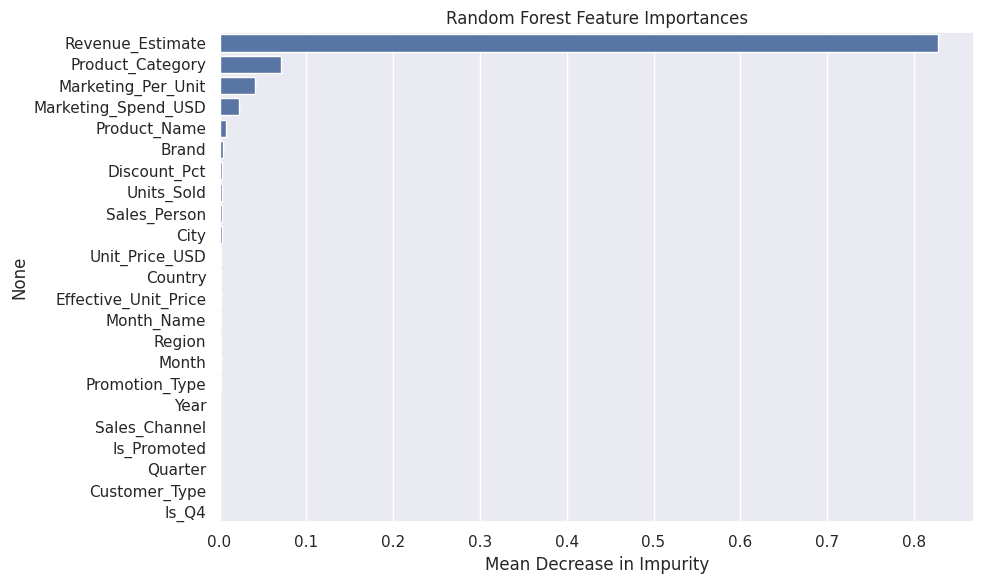

In [21]:
rf_model = models["Random Forest"]
feature_names = numeric_cols + categorical_cols
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importances")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

### 6.5 Best Model — Detailed Report

=== Best Model: Gradient Boosting ===
R²: 0.9675
RMSE: 42.93
MAE: 25.85

Residual Summary:
count    3648.00
mean        0.57
std        42.93
min      -304.11
25%       -14.66
50%        -0.98
75%        14.23
max       435.78
dtype: float64


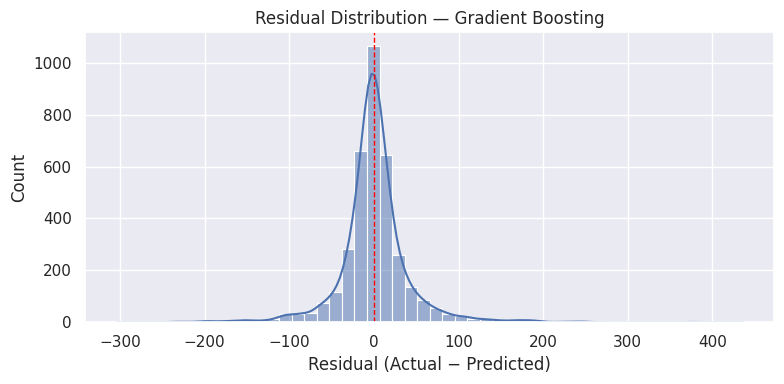

In [22]:
best_preds = best_model.predict(X_test_arr)
best_residuals = y_test.values - best_preds

print(f"=== Best Model: {best_model_name} ===")
print(f"R²: {r2_score(y_test, best_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, best_preds):.2f}")
print()
print("Residual Summary:")
print(pd.Series(best_residuals).describe().round(2))

# Residual distribution
plt.figure(figsize=(8, 4))
sns.histplot(best_residuals, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()